In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
# import arviz as az

import h5py
# import glob

import sxs

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

import ringdown as rd

In [3]:
t0 = 1126259462.423
ra = 1.952318922
dec = -1.26967171703
psi = 0.824043851821

In [22]:
### Fit object whose data was not line subtracted
fit = rd.Fit.from_config('/mnt/home/nkhusid/ceph/spec_inj/SXS_BBH_1156/mtot330/220_SXS_BBH_1156_fmin10Hz_ppSNR20_mtot330_edgeon/engine/1126259462.423000/config.ini')

### Fit object whose data WAS line subtracted
fit_sub = rd.Fit.from_config('/mnt/home/nkhusid/ceph/spec_inj/SXS_BBH_1156/mtot330/linesub/220_SXS_BBH_1156_fmin10Hz_ppSNR20_mtot330_edgeon/engine/1126259462.423000/config.ini')

### empty Fit object for comparison
temp_fit = rd.Fit()

In [23]:
### This is data WITHOUT line subtraction
wf = pd.read_hdf('/mnt/home/nkhusid/spec_inj/data/injections/SXS_BBH_1156/mtot330/SXS_BBH_1156_fmin10Hz_ppSNR20_mtot330_edgeon_H1.hdf5', key='H1')

### This is data WITH line subtraction
wf_sub = pd.read_hdf('/mnt/home/nkhusid/spec_inj/data/injections/SXS_BBH_1156/mtot330/linesub/SXS_BBH_1156_fmin10Hz_ppSNR20_mtot330_edgeon_H1.hdf5', key='H1')

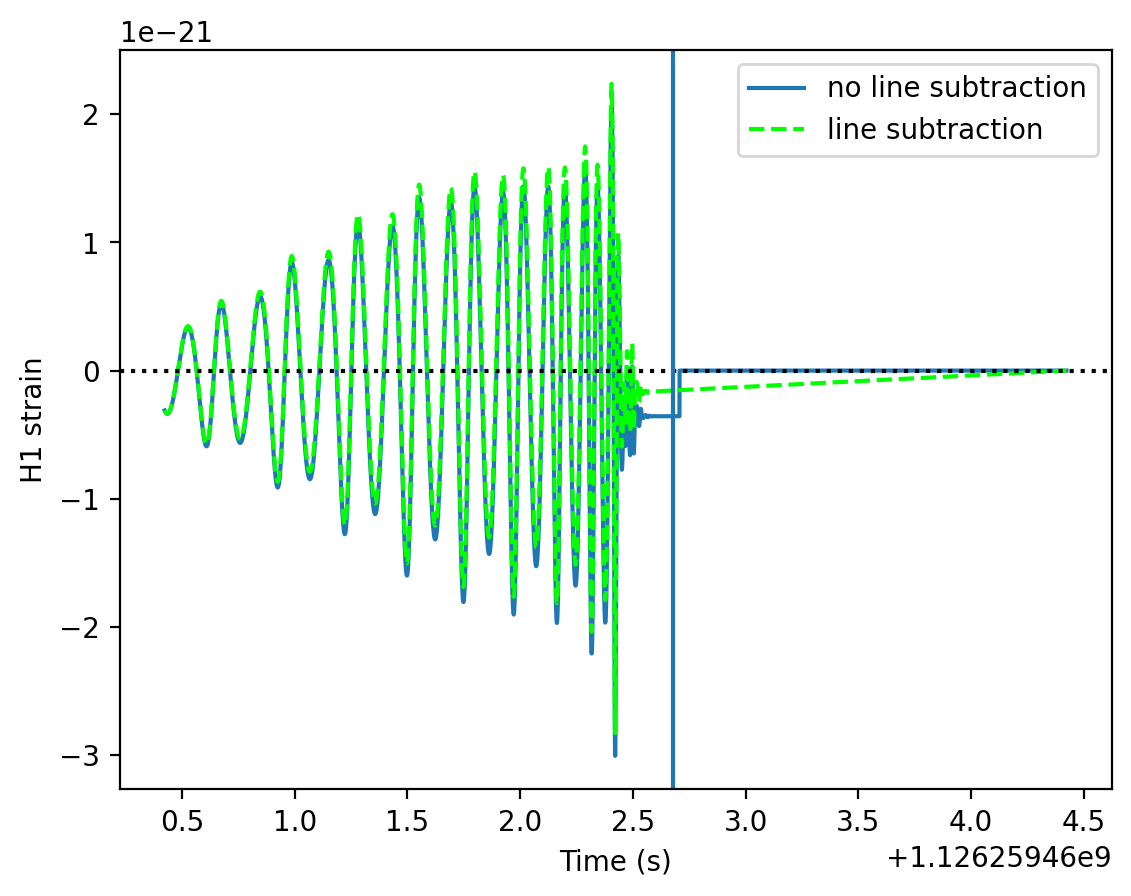

In [24]:
plt.plot(wf, label='no line subtraction')
plt.plot(wf_sub, ls='--', color='lime', label='line subtraction')
plt.axhline(0, c='k', ls=':')

padding_time = fit.start_times['H1'] + 0.24
plt.axvline(padding_time)

plt.xlabel('Time (s)')
plt.ylabel('H1 strain')

plt.legend()

### Upon injection, it seems the waveforms get padded with zeroes by default to fill out the time array

In [25]:
### Let's instead pad the waveform with roughly the final value of h from the sim

ipad = np.argmin(np.abs(wf.index.values - padding_time))
wf.iloc[ipad:] = wf.iloc[ipad]

Text(0, 0.5, 'H1 strain')

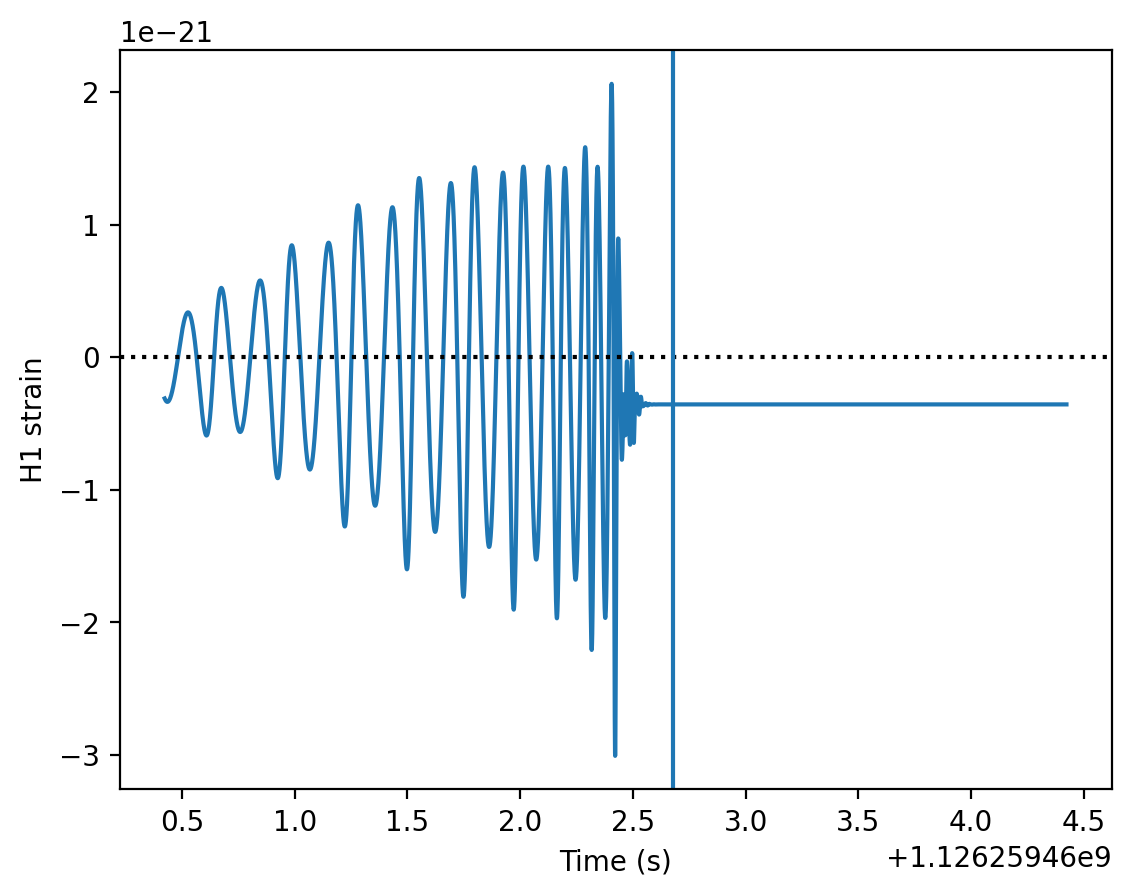

In [26]:
plt.plot(wf)
plt.axhline(0, c='k', ls=':')
plt.axvline(padding_time)

plt.xlabel('Time (s)')
plt.ylabel('H1 strain')

In [27]:
ts = sxs.TimeSeries(wf.values, time=wf.index.values)
ts_sub = ts.line_subtraction() ### apply line subtraction

Text(0, 0.5, 'H1 strain')

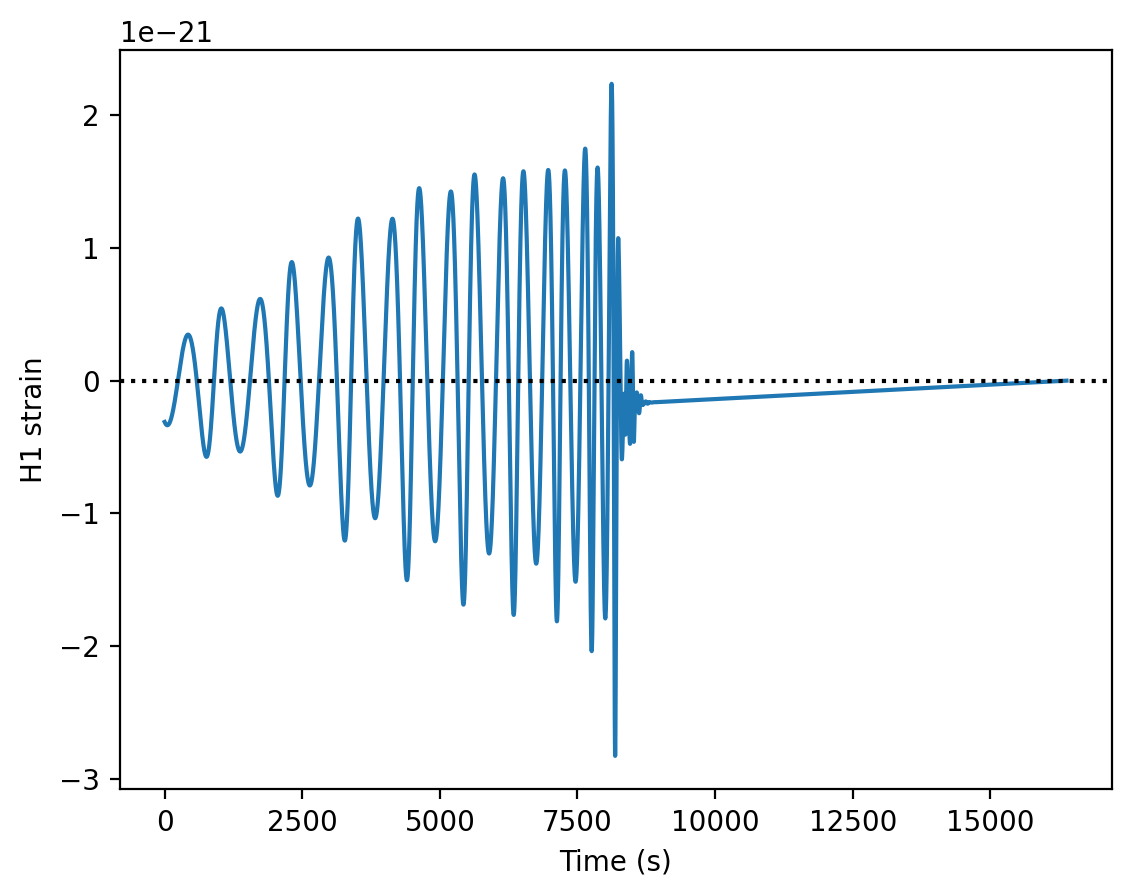

In [28]:
plt.plot(ts_sub)
plt.axhline(0, c='k', ls=':')

plt.xlabel('Time (s)')
plt.ylabel('H1 strain')

In [29]:
temp_fit.add_data(rd.Data(ts_sub.ndarray, index=ts_sub.time, ifo='H1'))

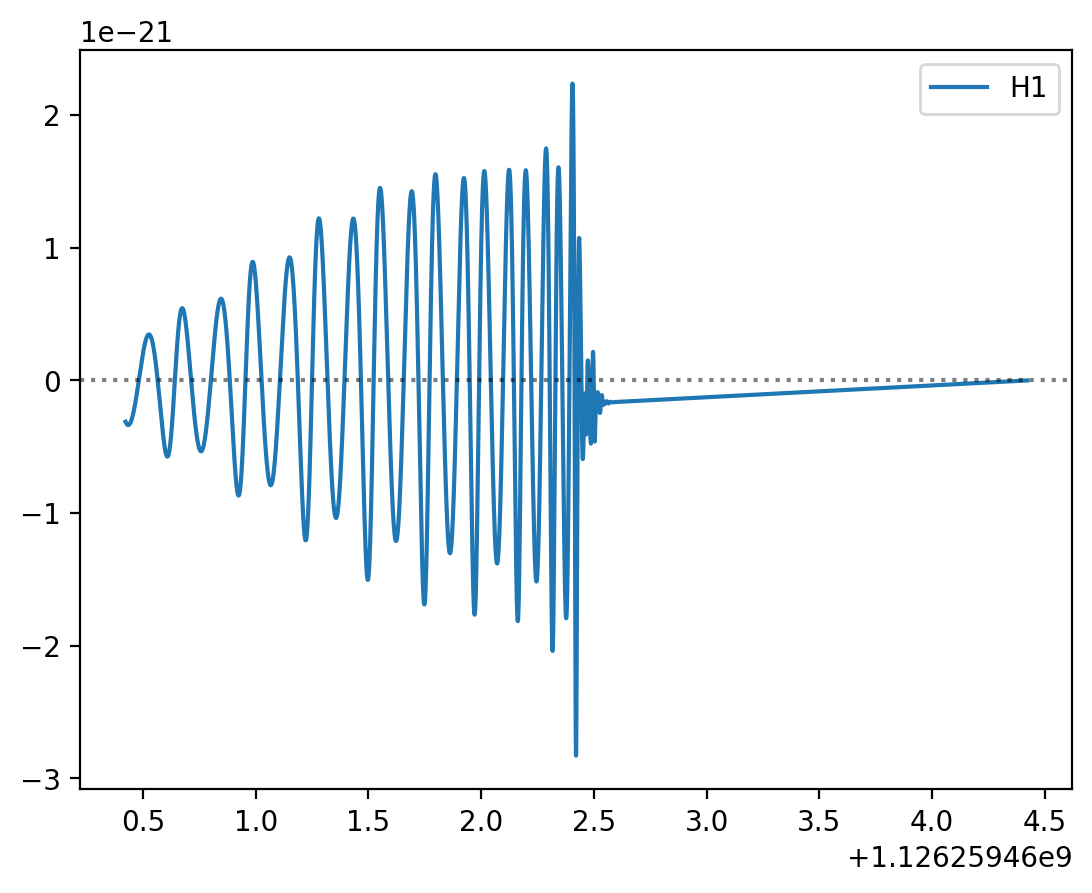

In [30]:
for i, d in temp_fit.data.items():
    plt.plot(d, label=i)

plt.axhline(0, color='k', ls=':', alpha=0.5)
plt.legend()

In [31]:
temp_fit.set_target(t0=t0, 
                ra=ra, 
                dec=dec, 
                psi=psi, 
                duration=0.5)

In [32]:
temp_fit.condition_data(f_min=10, ds=1, trim=0)

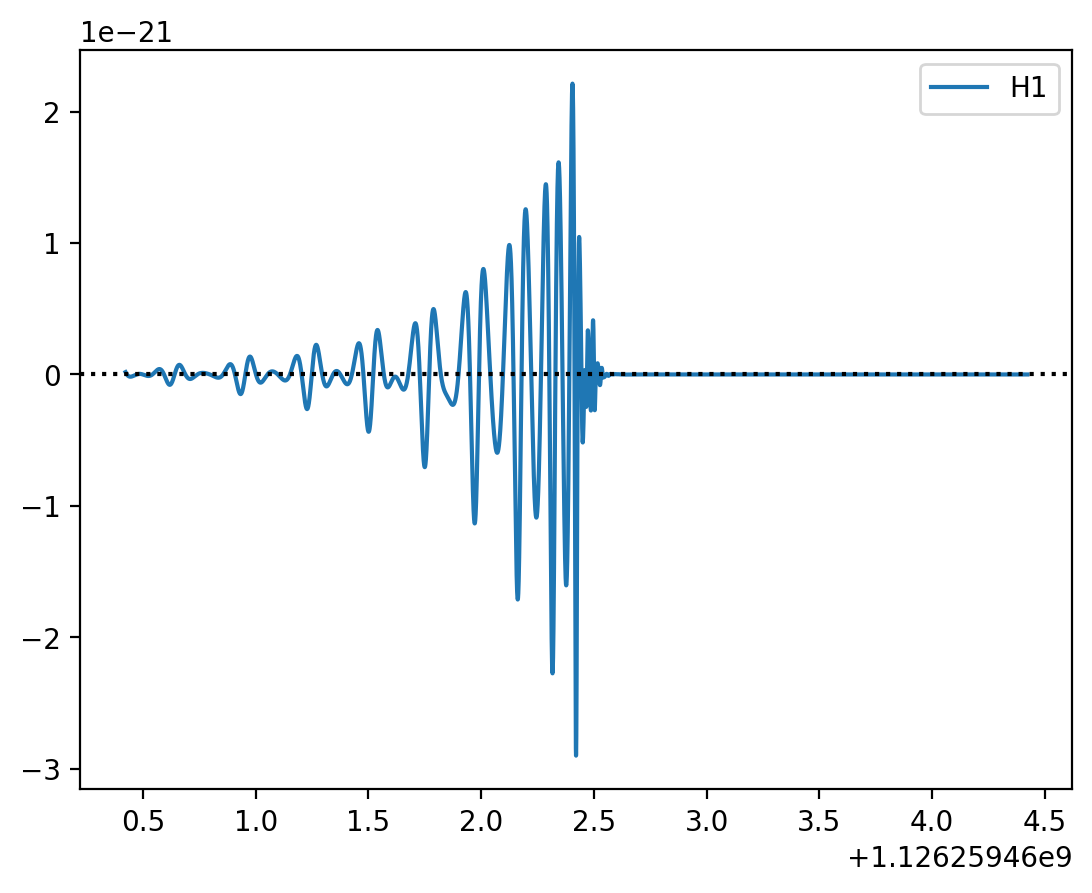

In [33]:
for i, d in temp_fit.data.items():
    plt.plot(d, label=i)
plt.axhline(0, c='k', ls=':')

plt.legend()

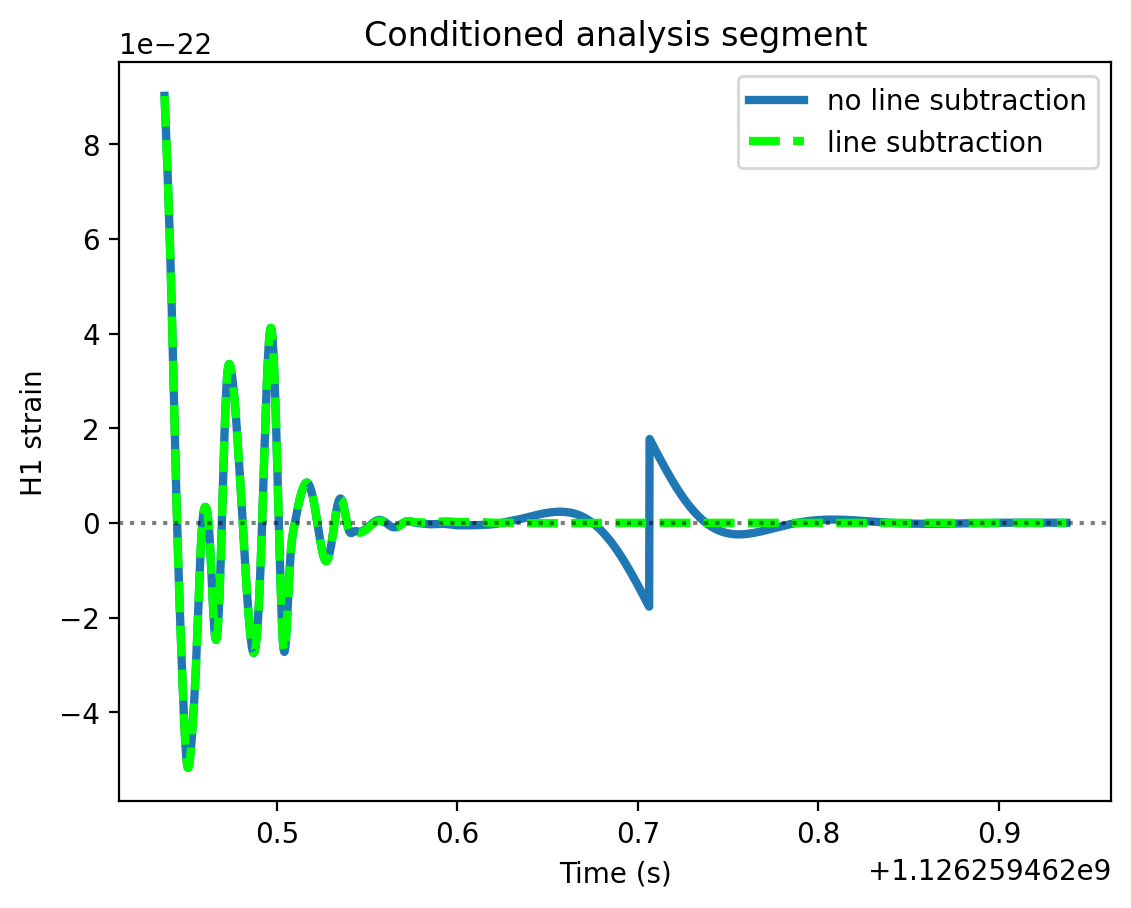

In [34]:
plt.plot(fit.analysis_data['H1'], lw=3, label='no line subtraction')
plt.plot(temp_fit.analysis_data['H1'], ls='--', color='lime', lw=3, label='line subtraction')
plt.axhline(0, color='k', ls=':', alpha=0.5)

plt.xlabel('Time (s)')
plt.ylabel('H1 strain')
plt.title('Conditioned analysis segment')

plt.legend()

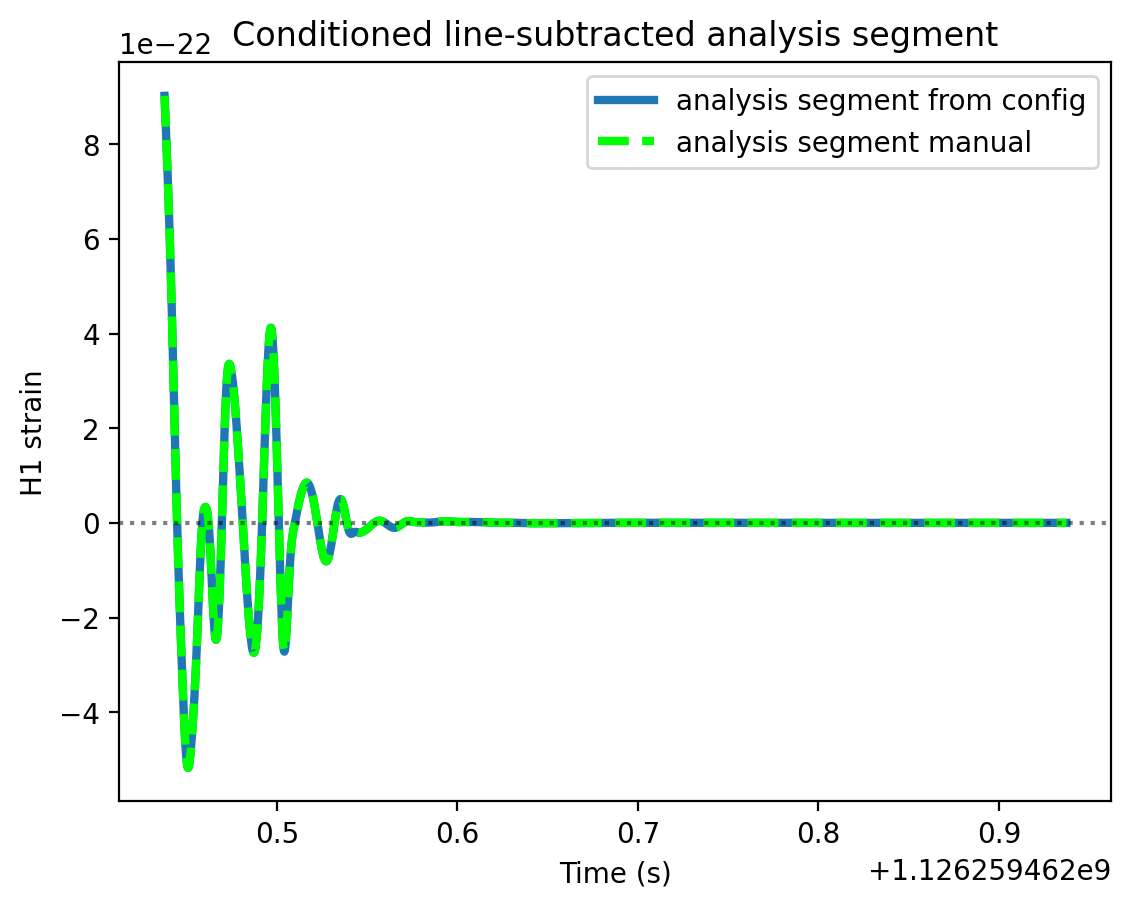

In [35]:
plt.plot(fit_sub.analysis_data['H1'], lw=3, label='analysis segment from config')
plt.plot(temp_fit.analysis_data['H1'], ls='--', color='lime', lw=3, label='analysis segment manual')
plt.axhline(0, color='k', ls=':', alpha=0.5)

plt.xlabel('Time (s)')
plt.ylabel('H1 strain')
plt.title('Conditioned line-subtracted analysis segment')

plt.legend()